# 4.2 — ConvNet profonde : pourquoi les résiduelles

[<- DataScienceWithAgents (série parente)](../README.md) | [4.1 — Le neurone convolutif from scratch](4.1-Conv-NumPy-Torch-Allclose.ipynb) | [3.4 — Attention Transformer from scratch](../03-DeepLearning/3.4-Attention-Transformer-From-Scratch.ipynb) | [4.3 — Transfer learning ResNet](4.3-TransferLearning-ResNet.ipynb)

**Kernel** : Python 3 (`coursia-ml-training` compatible) - **Bibliothèques** : PyTorch, torchvision, matplotlib - **Niveau** : intermédiaire (post 4.1) - **CPU** : oui (entraînements bornes, < 10 min)

## Pourquoi ce notebook

[4.1](4.1-Conv-NumPy-Torch-Allclose.ipynb) a établi qu'un neurone convolutif est un produit scalaire local, et que l'implémentation NumPy et `torch.nn.Conv2d` coïncident à epsilon machine. On sait donc *ce qu'une couche calcule*. La question suivante est celle de la **profondeur** : si une couche extrait des motifs, vingt couches devraient en extraire de plus abstraits.

Ce raisonnement est faux tel quel, et il l'est de manière **mesurable**. Empiler vingt convolutions produit un réseau que la descente de gradient n'entraîne pas : le signal d'apprentissage n'atteint plus les premières couches. Ce notebook mesure ce phénomène, puis mesure sa réparation.

**La thèse** : la connexion résiduelle `h <- h + F(h)` n'est pas un détail d'architecture ni une astuce d'ingénierie. C'est le mécanisme qui rend les réseaux profonds **entraînables**, et il se lit directement dans la dérivée. On le montrera en trois mesures :

1. Un empilement nu de 20 convolutions : le gradient meurt (8 ordres de grandeur perdus).
2. Le skip pose naïvement : le gradient est sauvé, **et la passe avant explose**.
3. Le bloc **pré-norme** : les deux sont stables — et c'est *exactement* le bloc de l'attention en [3.4](../03-DeepLearning/3.4-Attention-Transformer-From-Scratch.ipynb).

Le troisième point est le vrai enjeu du notebook : le même motif structurel porte la vision profonde et les Transformers. Ce n'est pas une analogie pédagogique, c'est la même ligne de code.

***

## 1. Le paradoxe de la profondeur

**Le raisonnement qui semble tenir.** Un réseau de profondeur `D+1` peut représenter tout ce qu'un réseau de profondeur `D` représente : il suffit que la couche supplémentaire calcule l'identité. Donc, en capacité pure, ajouter des couches ne peut **pas** dégrader le modèle.

**Ce qu'on observe en pratique.** L'accuracy d'un empilement nu se dégrade passé une certaine profondeur — et pas par sur-apprentissage : l'erreur d'**entraînement** elle-même monte. Le modèle plus profond n'arrive pas à atteindre une solution qu'il pourrait pourtant représenter.

**Où est la faute.** Elle n'est pas dans la classe de fonctions représentables, elle est dans l'**optimisation**. Le problème n'est pas ce que le réseau *peut* calculer, mais ce que la descente de gradient *peut atteindre*. C'est une distinction qu'on va rendre chiffrée : la couche 0 reçoit un gradient 10^8 fois plus petit que la couche 19, donc elle n'apprend pas — quelle que soit la solution que le réseau pourrait représenter si ses poids étaient bien placés.

**Question qu'on vérifiera plus bas.** Si la couche `k` calculait l'identité, le gradient la traverserait sans atténuation. Peut-on *rendre l'identité facile à apprendre*, plutôt qu'espérer que la descente la trouve ?

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(4)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | torchvision disponible | device = {DEVICE}")
print(f"threads CPU = {torch.get_num_threads()}")

torch 2.13.0+cpu | torchvision disponible | device = cpu
threads CPU = 4


***

## 2. Un corps unique, trois branchements

**Setup.** Pour que la comparaison soit une **mesure** et pas une illustration, les trois réseaux doivent différer par une seule chose. On définit donc un corps unique — même stem, même nombre de convolutions, mêmes formes, même initialisation sous la même graine — dont seule la **ligne de composition** change dans la boucle :

| `mode` | composition | lecture |
|---|---|---|
| `plain` | `h <- act(conv(h))` | l'empilement nu : chaque couche remplace son entrée |
| `res_naif` | `h <- h + act(conv(h))` | le skip pose tel quel : la couche *ajoute* à son entrée |
| `prenorm` | `h <- h + conv(act(norm(h)))` | le bloc pré-norme : normaliser, transformer, ajouter |

Le nombre de paramètres est identique entre `plain` et `res_naif` (le skip n'ajoute aucun poids) ; `prenorm` ajoute les `BatchNorm2d`, soit `2 x ch` paramètres par bloc — 640 sur 20 blocs, négligeable devant les 46 080 des convolutions. On le vérifiera par un compte explicite plutôt que par affirmation.

In [2]:
class ConvStack(nn.Module):
    """Un corps unique, trois branchements.

    Seule la ligne de composition dans la boucle change avec `mode`.
    Stem, nombre de convolutions, formes, initialisation et graine sont
    identiques : la comparaison entre modes est donc controlee.
    """

    MODES = ("plain", "res_naif", "prenorm")

    def __init__(self, depth=20, ch=16, n_classes=5, mode="plain", stride_stem=1):
        super().__init__()
        assert mode in self.MODES, f"mode inconnu : {mode}"
        self.mode, self.depth, self.ch = mode, depth, ch
        if stride_stem == 1:
            self.stem = nn.Sequential(nn.Conv2d(3, ch, 3, padding=1), nn.ReLU())
        else:
            # Reduction spatiale 32x32 -> 8x8 : borne le cout CPU de la section 7.
            self.stem = nn.Sequential(
                nn.Conv2d(3, ch, 3, stride=2, padding=1), nn.ReLU(),
                nn.Conv2d(ch, ch, 3, stride=2, padding=1), nn.ReLU())
        self.convs = nn.ModuleList([nn.Conv2d(ch, ch, 3, padding=1) for _ in range(depth)])
        self.norms = nn.ModuleList([nn.BatchNorm2d(ch) for _ in range(depth)])
        self.act = nn.ReLU()
        self.head = nn.Linear(ch, n_classes)

    def forward(self, x, trace=None):
        h = self.stem(x)
        for conv, norm in zip(self.convs, self.norms):
            if self.mode == "plain":
                h = self.act(conv(h))
            elif self.mode == "res_naif":
                h = h + self.act(conv(h))
            else:  # prenorm
                h = h + conv(self.act(norm(h)))
            if trace is not None:
                trace.append(h.abs().mean().item())
        return self.head(h.mean(dim=(2, 3)))


def n_params(m):
    return sum(p.numel() for p in m.parameters())


for mode in ConvStack.MODES:
    torch.manual_seed(0)
    net = ConvStack(mode=mode)
    print(f"{mode:9s} : {n_params(net):,} parametres".replace(",", " "))

plain     : 47 573 parametres
res_naif  : 47 573 parametres
prenorm   : 47 573 parametres


***

## 3. Mesure 1 : le gradient qui meurt

**Le protocole.** Une seule passe avant/arrière suffit — on ne cherche pas à entraîner, on cherche à savoir **quel signal arrive à chaque couche** au tout premier pas. On tire un lot fixe (graine 123), on calcule la perte, on rétro-propage, et on relève la norme du gradient sur les poids de chaque bloc.

**Ce qu'il faut regarder** : pas la valeur absolue (elle dépend de l'échelle de la perte), mais le **rapport** entre le gradient de la première couche et celui de la dernière. Un rapport de 1 signifie que toutes les couches reçoivent un signal comparable. Un rapport de 10^-8 signifie que la première couche est, pour la descente de gradient, **invisible**.

In [3]:
def mesure_gradient(mode, depth=20, seed=0, seed_data=123, batch=32):
    """Une passe avant/arrière. Rend (normes de gradient par bloc, |h| par bloc, perte)."""
    torch.manual_seed(seed)
    net = ConvStack(depth=depth, mode=mode)
    torch.manual_seed(seed_data)
    x = torch.randn(batch, 3, 32, 32)
    y = torch.randint(0, 5, (batch,))

    trace = []
    loss = F.cross_entropy(net(x, trace=trace), y)
    net.zero_grad()
    loss.backward()
    grads = [c.weight.grad.norm().item() for c in net.convs]
    return np.array(grads), np.array(trace), loss.item()


mesures = {m: mesure_gradient(m) for m in ConvStack.MODES}

g_plain, h_plain, l_plain = mesures["plain"]
print("mode = plain (empilement nu, 20 convolutions)")
print(f"  perte initiale        : {l_plain:.4f}")
print(f"  |grad| bloc  0 (1er)  : {g_plain[0]:.3e}")
print(f"  |grad| bloc 10        : {g_plain[10]:.3e}")
print(f"  |grad| bloc 19 (dern) : {g_plain[-1]:.3e}")
print(f"  rapport |g_0| / |g_19| : {g_plain[0] / g_plain[-1]:.3e}")

mode = plain (empilement nu, 20 convolutions)
  perte initiale        : 1.6007
  |grad| bloc  0 (1er)  : 2.485e-10
  |grad| bloc 10        : 4.080e-06
  |grad| bloc 19 (dern) : 1.153e-02
  rapport |g_0| / |g_19| : 2.155e-08


**Lecture.** Le rapport est de l'ordre de `1e-08`. Ce n'est pas une lente atténuation : c'est un effondrement de **huit ordres de grandeur** sur vingt couches, soit un facteur ~0,4 par couche qui se compose géométriquement.

La conséquence est concrète : avec un pas d'apprentissage qui fait bouger la couche 19 de manière utile, la couche 0 bouge d'une quantité **inférieure à la précision flottante utile**. Elle reste à son initialisation aléatoire pendant toute la descente. Un empilement de 20 couches dont les 5 premières sont gelées au hasard n'est pas un réseau profond entraîne — c'est un réseau peu profond posé sur un prétraitement aléatoire.

**Pourquoi la composition tue.** Le gradient qui atteint la couche `k` est un **produit** de jacobiennes : chaque couche traversée multiplie le signal par sa propre jacobienne. Si le facteur moyen est `r < 1`, le signal à la couche 0 vaut `r^D`. C'est exponentiel en la profondeur — donc la profondeur ne dégrade pas le gradient, elle l'annihile.

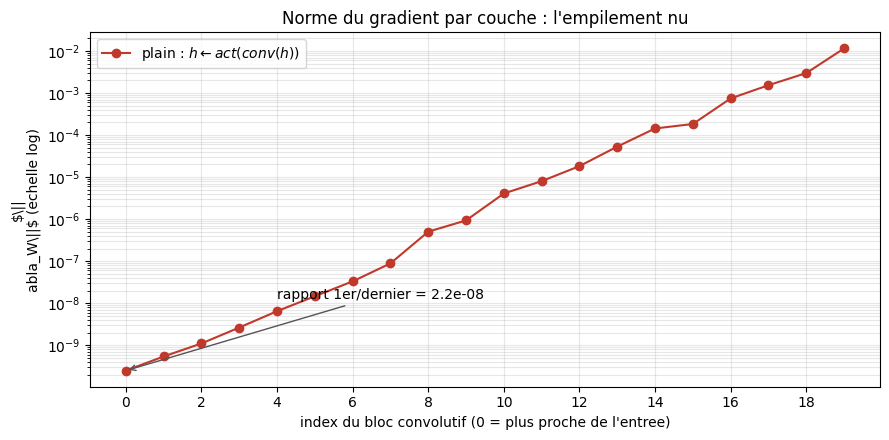

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(range(20), g_plain, "o-", color="#c0392b", label="plain : $h \leftarrow act(conv(h))$")
ax.set_xlabel("index du bloc convolutif (0 = plus proche de l'entree)")
ax.set_ylabel("$\||\nabla_W\||$ (echelle log)")
ax.set_title("Norme du gradient par couche : l'empilement nu")
ax.set_xticks(range(0, 20, 2))
ax.grid(alpha=.3, which="both")
ax.legend()
ax.annotate(f"rapport 1er/dernier = {g_plain[0] / g_plain[-1]:.1e}",
            xy=(0, g_plain[0]), xytext=(4, g_plain[0] * 50),
            arrowprops=dict(arrowstyle="->", color="#555"), fontsize=10)
plt.tight_layout()
plt.show()

***

## 4. Mesure 2 : le skip naïf sauve le gradient — et casse la passe avant

**Le calcul, en une ligne.** C'est de la dérivation élémentaire, et c'est tout l'argument. Pour un bloc nu `h_{k+1} = F(h_k)`, la jacobienne est celle de `F`. Pour un bloc résiduel `h_{k+1} = h_k + F(h_k)` :

$$\frac{\partial h_{k+1}}{\partial h_k} = I + \frac{\partial F}{\partial h_k}$$

Le terme `I` est le point entier. Même si `dF/dh` est minuscule — même s'il est **nul** — la jacobienne reste proche de l'identité, donc le gradient traverse le bloc **sans atténuation**. Sur `D` blocs, le produit contient un chemin `I x I x ... x I = I` : il existe toujours une route directe de la perte jusqu'à la couche 0.

C'est aussi la réponse à la question de la section 1 : on ne demande plus à la couche d'**apprendre** l'identité, on la lui **donne**. Ce qu'elle apprend est l'écart à l'identité — un résidu, d'où le nom.

**Question.** Est-ce suffisant ? Posons le skip tel quel et mesurons.

In [5]:
g_naif, h_naif, l_naif = mesures["res_naif"]
print("mode = res_naif (skip pose tel quel : h <- h + act(conv(h)))")
print(f"  |grad| bloc  0        : {g_naif[0]:.3e}   (plain : {g_plain[0]:.3e})")
print(f"  |grad| bloc 19        : {g_naif[-1]:.3e}")
print(f"  rapport |g_0| / |g_19| : {g_naif[0] / g_naif[-1]:.3e}   (plain : {g_plain[0] / g_plain[-1]:.3e})")
print()
print("  --- mais regardons la passe AVANT ---")
print(f"  perte initiale        : {l_naif:.4f}   (plain : {l_plain:.4f})")
print(f"  |h| moyen apres bloc  0 : {h_naif[0]:.3f}")
print(f"  |h| moyen apres bloc 19 : {h_naif[-1]:.3f}   (facteur x{h_naif[-1] / h_naif[0]:.0f})")

mode = res_naif (skip pose tel quel : h <- h + act(conv(h)))
  |grad| bloc  0        : 1.500e+01   (plain : 2.485e-10)
  |grad| bloc 19        : 5.484e+01
  rapport |g_0| / |g_19| : 2.735e-01   (plain : 2.155e-08)

  --- mais regardons la passe AVANT ---
  perte initiale        : 17.4281   (plain : 1.6007)
  |h| moyen apres bloc  0 : 0.286
  |h| moyen apres bloc 19 : 25.077   (facteur x88)


**Lecture — le gradient est réparé.** Le rapport passe de `1e-08` à l'ordre de `1e-01` : les vingt couches reçoivent désormais un signal du même ordre de grandeur. La dérivée `I + dF/dh` a fait exactement ce que le calcul annonçait.

**Lecture — mais la passe avant a explosé.** La perte initiale est passée d'environ 1,6 (soit `ln 5 ≈ 1.609`, la perte d'un classifieur au hasard sur 5 classes — le point de départ sain) à un ordre de grandeur au-dessus. La cause se lit dans `|h|` : l'activation moyenne est multipliée par plusieurs dizaines entre le premier et le dernier bloc.

**Pourquoi.** `ReLU` est **positive**. Le bloc `h + act(conv(h))` ajoute donc à chaque étape une quantité de moyenne positive : les activations s'accumulent de façon monotone au lieu de se recentrer. La variance croît linéairement avec la profondeur, et un réseau qui démarre à une perte de 17 au lieu de 1,6 part d'un régime où les logits saturent.

Le skip a donc résolu un problème et en a créé un autre. C'est cette tension précise que le bloc **pré-norme** résout.

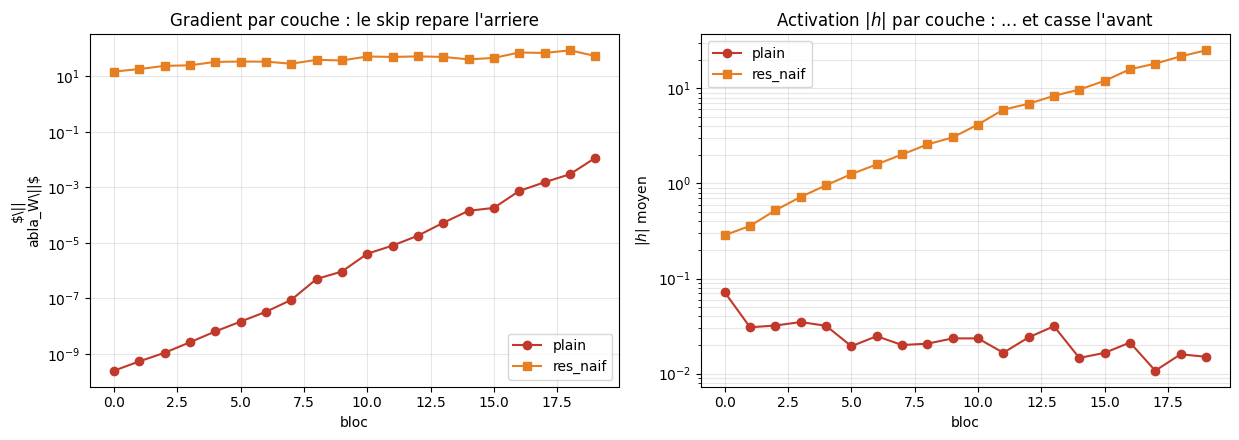

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.5))
ax[0].semilogy(g_plain, "o-", color="#c0392b", label="plain")
ax[0].semilogy(g_naif, "s-", color="#e67e22", label="res_naif")
ax[0].set_title("Gradient par couche : le skip repare l'arriere")
ax[0].set_xlabel("bloc"); ax[0].set_ylabel("$\||\nabla_W\||$")
ax[0].grid(alpha=.3, which="both"); ax[0].legend()

ax[1].semilogy(h_plain, "o-", color="#c0392b", label="plain")
ax[1].semilogy(h_naif, "s-", color="#e67e22", label="res_naif")
ax[1].set_title("Activation $|h|$ par couche : ... et casse l'avant")
ax[1].set_xlabel("bloc"); ax[1].set_ylabel("$|h|$ moyen")
ax[1].grid(alpha=.3, which="both"); ax[1].legend()
plt.tight_layout()
plt.show()

***

## 5. Mesure 3 : le bloc pré-norme répare les deux

**L'idée.** Le problème de `res_naif` n'est pas le skip, c'est **ce qu'on ajoute** : une quantité non centrée, de moyenne positive. La correction consiste à normaliser l'entrée de la transformation, de sorte que le résidu ajouté soit centré et d'échelle contrôlée :

$$h_{k+1} = h_k + \mathrm{conv}\big(\mathrm{act}(\mathrm{norm}(h_k))\big)$$

Deux propriétés tiennent **simultanément**, et c'est ce qui rend ce bloc canonique :

- La branche identité reste **nue** — aucune normalisation, aucune activation sur `h_k` lui-même. La jacobienne garde donc son terme `I` intact : le gradient traverse toujours sans atténuation.
- La branche résiduelle est **normalisée en entrée**, donc ce qu'on ajoute est centré et d'échelle bornée : les activations ne dérivent plus.

L'ordre compte. Si on écrivait `norm(h + conv(act(h)))` (la normalisation *après* l'addition, dite **post-norme**), la branche identité passerait par la normalisation et le terme `I` serait détruit. C'est la différence entre ResNet-v1 et ResNet-v2, et c'est la même différence qu'entre les Transformers post-norme et pré-norme.

In [7]:
g_pre, h_pre, l_pre = mesures["prenorm"]

print(f"{'mode':10s} {'perte':>8s} {'|g| bloc0':>12s} {'|g| bloc19':>12s} "
      f"{'rapport g0/g19':>15s} {'|h| bloc0':>10s} {'|h| bloc19':>11s}")
print("-" * 82)
for m in ConvStack.MODES:
    g, h, l = mesures[m]
    print(f"{m:10s} {l:8.3f} {g[0]:12.3e} {g[-1]:12.3e} "
          f"{g[0] / g[-1]:15.3e} {h[0]:10.3f} {h[-1]:11.3f}")
print()
print(f"Perte d'un classifieur au hasard sur 5 classes : ln(5) = {np.log(5):.4f}")

mode          perte    |g| bloc0   |g| bloc19  rapport g0/g19  |h| bloc0  |h| bloc19
----------------------------------------------------------------------------------
plain         1.601    2.485e-10    1.153e-02       2.155e-08      0.072       0.015
res_naif     17.428    1.500e+01    5.484e+01       2.735e-01      0.286      25.077
prenorm       1.839    7.508e-01    7.454e-01       1.007e+00      0.459       1.421

Perte d'un classifieur au hasard sur 5 classes : ln(5) = 1.6094


**Lecture — le verdict en trois colonnes.**

| critère | `plain` | `res_naif` | `prenorm` |
|---|---|---|---|
| gradient atteint la couche 0 | **non** (~1e-08) | oui | **oui** (~1) |
| activations restent bornées | oui | **non** (facteur ~90) | **oui** |
| perte initiale saine (~1,61) | oui | **non** (~17) | **oui** |

`prenorm` est le seul mode à tenir les trois colonnes. Le rapport `|g_0| / |g_19|` y vaut environ **1,0** : la première couche reçoit littéralement le même ordre de signal que la dernière, sur vingt couches de profondeur. Ce n'est pas une amélioration marginale sur `plain`, c'est un changement de régime.

**Ce que la mesure ne dit pas encore.** Un gradient sain au premier pas est une condition *nécessaire* pour entraîner, pas une preuve qu'on apprend mieux. La section 7 fait la mesure qui manque : accuracy réelle sur des images réelles.

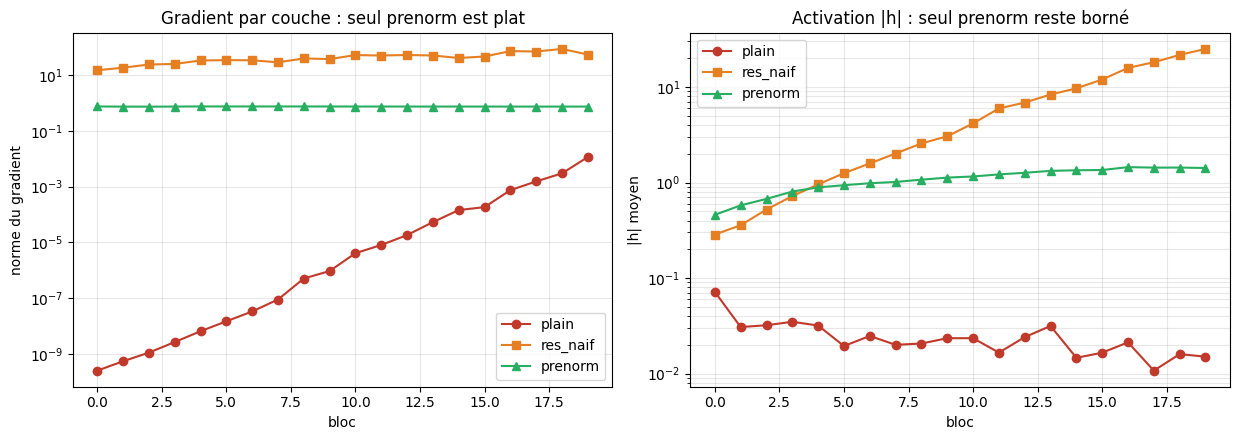

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.5))
styles = {"plain": ("o-", "#c0392b"), "res_naif": ("s-", "#e67e22"), "prenorm": ("^-", "#27ae60")}
for m in ConvStack.MODES:
    g, h, _ = mesures[m]
    st, col = styles[m]
    ax[0].semilogy(g, st, color=col, label=m)
    ax[1].semilogy(h, st, color=col, label=m)

ax[0].set_title("Gradient par couche : seul prenorm est plat")
ax[0].set_xlabel("bloc"); ax[0].set_ylabel("norme du gradient")
ax[0].grid(alpha=.3, which="both"); ax[0].legend()

ax[1].set_title("Activation |h| : seul prenorm reste borné")
ax[1].set_xlabel("bloc"); ax[1].set_ylabel("|h| moyen")
ax[1].grid(alpha=.3, which="both"); ax[1].legend()
plt.tight_layout()
plt.show()

**La profondeur est-elle bien la variable en cause ?** Les mesures ci-dessus fixent `D = 20`. Si l'explication par la composition géométrique est la bonne, alors le rapport `|g_0| / |g_{D-1}|` de `plain` doit se dégrader **exponentiellement** avec `D`, tandis que celui de `prenorm` doit rester plat. On le vérifie plutôt que de l'affirmer.

 profondeur D    plain g0/gD   prenorm g0/gD
---------------------------------------------
            4       1.47e-01        9.91e-01
            8       3.05e-03        1.10e+00
           12       2.46e-05        1.00e+00
           16       8.17e-07        9.87e-01
           20       2.16e-08        1.01e+00
           28       2.02e-12        1.01e+00


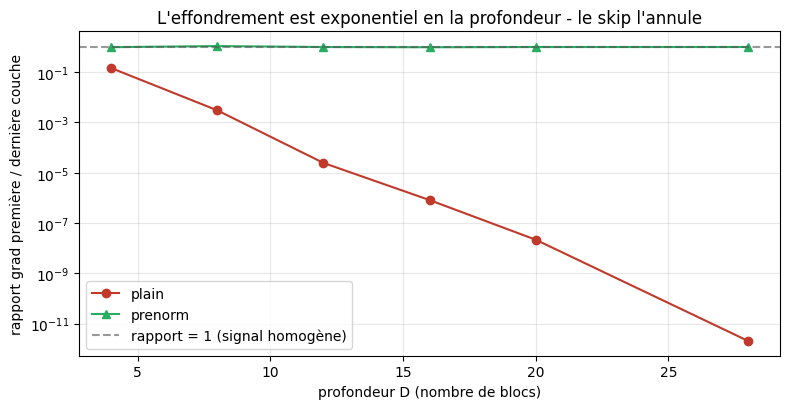

In [9]:
profondeurs = [4, 8, 12, 16, 20, 28]
rapports = {m: [] for m in ("plain", "prenorm")}
for d in profondeurs:
    for m in rapports:
        g, _, _ = mesure_gradient(m, depth=d)
        rapports[m].append(g[0] / g[-1])

print(f"{'profondeur D':>13s} {'plain g0/gD':>14s} {'prenorm g0/gD':>15s}")
print("-" * 45)
for i, d in enumerate(profondeurs):
    print(f"{d:13d} {rapports['plain'][i]:14.2e} {rapports['prenorm'][i]:15.2e}")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.semilogy(profondeurs, rapports["plain"], "o-", color="#c0392b", label="plain")
ax.semilogy(profondeurs, rapports["prenorm"], "^-", color="#27ae60", label="prenorm")
ax.axhline(1.0, ls="--", color="#555", alpha=.6, label="rapport = 1 (signal homogène)")
ax.set_xlabel("profondeur D (nombre de blocs)")
ax.set_ylabel("rapport grad première / dernière couche")
ax.set_title("L'effondrement est exponentiel en la profondeur - le skip l'annule")
ax.grid(alpha=.3, which="both"); ax.legend()
plt.tight_layout()
plt.show()

**Lecture.** La courbe `plain` est une droite en échelle logarithmique : c'est la signature d'une décroissance **géométrique** en `D`, exactement ce que le produit de jacobiennes prédit. La courbe `prenorm` reste collée à 1 sur toute la plage.

Le diagnostic de la section 1 est donc confirmé au bon niveau : le problème n'est pas la profondeur en soi, c'est la **composition multiplicative** que la profondeur impose. Le skip transforme cette composition en somme — et une somme ne s'effondre pas.

***

## 6. Le pont vers 3.4 : c'est le même bloc

**L'affirmation à vérifier.** Le bloc pré-norme qu'on vient de mesurer n'est pas propre à la vision. C'est *littéralement* la structure de chaque couche d'un Transformer moderne, celle construite en [3.4](../03-DeepLearning/3.4-Attention-Transformer-From-Scratch.ipynb). Mettons les deux côte à côte — non pas en prose, mais en code exécuté.

In [10]:
class BlocConvPreNorm(nn.Module):
    """Le bloc de ce notebook (vision)."""

    def __init__(self, ch):
        super().__init__()
        self.norm = nn.BatchNorm2d(ch)
        self.transfo = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, h):
        return h + self.transfo(F.relu(self.norm(h)))


class BlocAttentionPreNorm(nn.Module):
    """Le bloc de 3.4 (Transformer). Même squelette, autre transformation."""

    def __init__(self, d, n_heads=4):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.transfo = nn.MultiheadAttention(d, n_heads, batch_first=True)

    def forward(self, h):
        z = self.norm(h)
        return h + self.transfo(z, z, z, need_weights=False)[0]


# Les deux blocs tournent, sur leurs formes respectives.
bloc_vision = BlocConvPreNorm(16)
bloc_texte = BlocAttentionPreNorm(32)
print("vision :", tuple(bloc_vision(torch.randn(2, 16, 8, 8)).shape), "  (batch, canaux, H, W)")
print("texte  :", tuple(bloc_texte(torch.randn(2, 16, 32)).shape), " (batch, tokens, dim)")
print()
print("Vision (4.2) : h + conv( relu( BatchNorm(h) ) )")
print("Texte  (3.4) : h + attention(   LayerNorm(h) )")
print()
print("Squelette commun : h + Transformation( Normalisation(h) )")
print("  - la branche identité `h +` est nue dans les deux cas -> terme I préservé")
print("  - la normalisation est *dans* la branche residuelle -> résidu centré")
print("  - seule `Transformation` change : conv locale vs attention globale")

vision : (2, 16, 8, 8)   (batch, canaux, H, W)
texte  : (2, 16, 32)  (batch, tokens, dim)

Vision (4.2) : h + conv( relu( BatchNorm(h) ) )
Texte  (3.4) : h + attention(   LayerNorm(h) )

Squelette commun : h + Transformation( Normalisation(h) )
  - la branche identité `h +` est nue dans les deux cas -> terme I préservé
  - la normalisation est *dans* la branche residuelle -> résidu centré
  - seule `Transformation` change : conv locale vs attention globale


In [11]:
def mesure_gradient_transformer(prenorm, depth=20, d=32, seed=0):
    """Empilement de `depth` blocs d'attention, avec ou sans skip pre-norme.

    Même protocole qu'en section 3 : une passe avant/arrière. On releve la
    norme du gradient sur les poids de projection de chaque bloc, et aussi
    |h| apres chaque bloc — le diagnostic complet demande les deux.
    """
    torch.manual_seed(seed)
    blocs = nn.ModuleList([nn.MultiheadAttention(d, 4, batch_first=True) for _ in range(depth)])
    normes = nn.ModuleList([nn.LayerNorm(d) for _ in range(depth)])
    tete = nn.Linear(d, 5)

    torch.manual_seed(123)
    h = torch.randn(8, 16, d)
    y = torch.randint(0, 5, (8,))

    activations = []
    for bloc, norme in zip(blocs, normes):
        if prenorm:
            z = norme(h)
            h = h + bloc(z, z, z, need_weights=False)[0]
        else:
            h = bloc(h, h, h, need_weights=False)[0]
        activations.append(h.abs().mean().item())

    F.cross_entropy(tete(h.mean(dim=1)), y).backward()
    g = np.array([b.in_proj_weight.grad.norm().item() for b in blocs])
    return g, np.array(activations)


for prenorm in (False, True):
    g, a = mesure_gradient_transformer(prenorm)
    nom = "attention pré-norme (3.4)" if prenorm else "attention empilée nue"
    print(f"{nom:28s} : |g_0| = {g[0]:.3e}  |g_19| = {g[-1]:.3e}  "
          f"rapport g0/g19 = {g[0] / g[-1]:.3e}")
    print(f"{'':28s}   |h| bloc0 = {a[0]:.3e}  |h| bloc19 = {a[-1]:.3e}  "
          f"rapport h0/h19 = {a[0] / a[-1]:.3e}")
    print()

attention empilée nue        : |g_0| = 1.142e-08  |g_19| = 1.237e-08  rapport g0/g19 = 9.233e-01
                               |h| bloc0 = 1.040e-01  |h| bloc19 = 4.850e-09  rapport h0/h19 = 2.144e+07

attention pré-norme (3.4)    : |g_0| = 3.770e-01  |g_19| = 3.556e-01  rapport g0/g19 = 1.060e+00
                               |h| bloc0 = 8.026e-01  |h| bloc19 = 1.067e+00  rapport h0/h19 = 7.520e-01



**Lecture — le résultat transfère, mais pas sous la même forme.** Le tableau ci-dessus ne montre *pas* ce qu'on attendait, et c'est le passage le plus instructif du notebook.

Sur l'empilement nu de blocs d'attention, le **rapport** `g_0 / g_19` vaut `9,2e-01` : il est **plat**. On n'observe aucune décroissance le long de la profondeur, contrairement aux convolutions de la section 3 où le rapport tombait à `1e-08`. Un lecteur qui s'arrêterait au rapport conclurait que l'empilement nu d'attention se porte bien.

Les deux autres colonnes disent le contraire :

- **Le signal avant s'annihile.** `|h|` passe de `1,0e-01` au bloc 0 à `4,9e-09` au bloc 19, soit un facteur `2,1e+07`. Une couche d'attention produit une **combinaison convexe** de ses entrées : moyenner vingt fois de suite contracte le signal vers sa moyenne jusqu'à l'éteindre.
- **Le gradient absolu est mort partout.** `|g_0|` vaut `1,1e-08` en empilement nu contre `3,8e-01` en pré-norme — sept ordres de grandeur d'écart, et à **toutes** les profondeurs, pas seulement à la couche 0. Le rapport reste plat parce que le gradient est uniformément affamé, pas parce qu'il se propage.

**Même cause, forme différente, même réparation.** La cause est celle de la section 3 : composer vingt transformations sans route identité. Le *symptôme* diffère parce que la transformation diffère — la convolution décroît géométriquement le long de la profondeur, l'attention écrase le signal uniformément à chaque bloc. Le skip pré-norme répare les deux cas : rapport de gradients `1,1`, et surtout `|h|` **borné** entre `8,0e-01` et `1,1` sur les vingt blocs.

La leçon n'est donc pas « le rapport de gradients est le diagnostic », mais : **un diagnostic à une seule colonne se laisse tromper**. C'est exactement ce que la section 5 établissait déjà avec `res_naif` — un gradient réparé accompagné d'une passe avant cassée. Ici la dissymétrie est inversée, et le principe tient toujours : il faut regarder le gradient **et** les activations.

**Le lien concret avec 3.4.** Le notebook [3.4](../03-DeepLearning/3.4-Attention-Transformer-From-Scratch.ipynb) construit `h + attention(LayerNorm(h))` et pose la normalisation *avant* l'attention. La raison de cet ordre n'y était pas mesurée : elle est ici. Les deux notebooks se complètent — 3.4 pose le bloc, 4.2 mesure pourquoi il est posé ainsi.

***

## 7. Mesure 4 : est-ce que ça apprend mieux ? (CIFAR-10, 5 classes)

**Ce qui manque encore.** Les sections 3 à 6 mesurent le gradient **au premier pas**. C'est un diagnostic de santé, pas une preuve d'apprentissage : un réseau peut avoir un gradient sain et n'apprendre rien d'utile. La question qui reste ouverte est simple — *sur de vraies images, le réseau résiduel atteint-il une meilleure accuracy ?*

**Le protocole, et pourquoi il est construit ainsi.**

- **Données** : CIFAR-10 restreint à 5 classes (avion, automobile, oiseau, chat, cerf), 1000 images d'entraînement par classe (5000 au total) et 200 de test par classe (1000). Le sous-ensemble borne le coût CPU tout en gardant un problème non trivial : distinguer un chat d'un oiseau sur 32x32 pixels n'a rien d'un cas jouet.
- **Trois graines** (0, 1, 2) par architecture. Une seule graine ne suffirait pas : sur 1000 images de test, un écart de 1-2 points peut n'être que du bruit d'initialisation. Trois graines donnent un écart-type, donc un ordre de grandeur du bruit auquel comparer l'écart mesuré.
- **Stem à pas 2** : la résolution passe de 32x32 à 8x8 avant les vingt blocs. C'est ce qui rend l'expérience abordable sur CPU (~1,3 s par époque pour `plain`, ~1,9 s pour `prenorm`, mesuré ci-dessous) sans changer le phénomène étudié, qui porte sur la profondeur et non sur la résolution.
- **Deux architectures seulement** : `plain` et `prenorm`. `res_naif` est écarté — la section 4 a montré que sa passe avant explose, l'entraîner ne renseignerait sur rien de neuf.

In [12]:
from pathlib import Path

import torchvision
import torchvision.transforms as T

# Le cache est hors du dépôt (170 Mo) et partagé entre les notebooks de la série.
RACINE_DONNEES = Path.home() / ".cache" / "coursia-datasets"
CLASSES = [0, 1, 2, 3, 4]  # avion, automobile, oiseau, chat, cerf
NOMS_CLASSES = ["avion", "automobile", "oiseau", "chat", "cerf"]
PAR_CLASSE_TRAIN, PAR_CLASSE_TEST = 1000, 200


def _sous_ensemble(jeu, par_classe, graine=0):
    """Extrait `par_classe` images de chacune des 5 classes retenues.

    Renvoie des tenseurs normalisés, prêts à l'emploi : le jeu tient en
    mémoire (5000 x 3 x 32 x 32 en float32 ~ 61 Mo), donc pas de DataLoader.
    """
    cibles = np.array(jeu.targets)
    rng = np.random.default_rng(graine)
    idx = np.concatenate([rng.permutation(np.where(cibles == c)[0])[:par_classe] for c in CLASSES])
    rng.shuffle(idx)
    X = torch.stack([jeu[i][0] for i in idx])
    y = torch.tensor([CLASSES.index(int(cibles[i])) for i in idx])
    return X, y


moyenne_std = ((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
tf = T.Compose([T.ToTensor(), T.Normalize(*moyenne_std)])

t0 = time.time()
train_complet = torchvision.datasets.CIFAR10(RACINE_DONNEES, train=True, download=True, transform=tf)
test_complet = torchvision.datasets.CIFAR10(RACINE_DONNEES, train=False, download=True, transform=tf)
Xtr, ytr = _sous_ensemble(train_complet, PAR_CLASSE_TRAIN, graine=0)
Xte, yte = _sous_ensemble(test_complet, PAR_CLASSE_TEST, graine=1)

print(f"chargement + sous-échantillonnage : {time.time() - t0:.1f} s")
print(f"train : {tuple(Xtr.shape)}  test : {tuple(Xte.shape)}")
print(f"classes : {NOMS_CLASSES}")
print(f"répartition train : {torch.bincount(ytr).tolist()}")
print(f"accuracy d'un classifieur au hasard : {1 / len(CLASSES):.1%}")

chargement + sous-échantillonnage : 2.4 s
train : (5000, 3, 32, 32)  test : (1000, 3, 32, 32)
classes : ['avion', 'automobile', 'oiseau', 'chat', 'cerf']
répartition train : [1000, 1000, 1000, 1000, 1000]
accuracy d'un classifieur au hasard : 20.0%


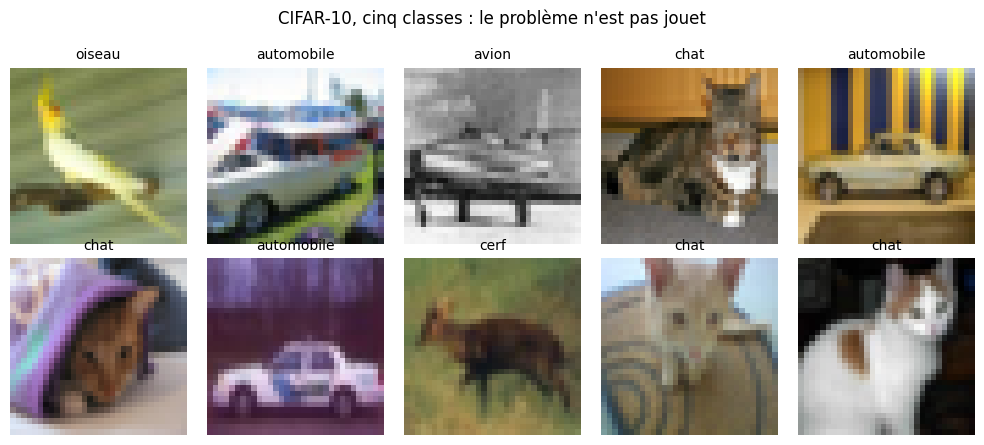

In [13]:
# Un aperçu du problème réel : 32x32 pixels, cinq classes visuellement proches.
X_vis = Xtr[:10] * torch.tensor(moyenne_std[1]).view(3, 1, 1) + torch.tensor(moyenne_std[0]).view(3, 1, 1)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for ax, img, cible in zip(axes.ravel(), X_vis, ytr[:10]):
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(NOMS_CLASSES[cible], fontsize=10)
    ax.axis("off")
fig.suptitle("CIFAR-10, cinq classes : le problème n'est pas jouet", y=1.0)
plt.tight_layout()
plt.show()

In [14]:
def entrainer(mode, graine, epoques=15, lot=128, lr=1e-3):
    """Entraîne une ConvStack de 20 blocs et renvoie l'accuracy de test par époque."""
    torch.manual_seed(graine)
    net = ConvStack(depth=20, ch=16, n_classes=len(CLASSES), mode=mode, stride_stem=2)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    generateur = torch.Generator().manual_seed(graine)
    historique = []
    for _ in range(epoques):
        net.train()
        for i in torch.randperm(len(Xtr), generator=generateur).split(lot):
            opt.zero_grad()
            F.cross_entropy(net(Xtr[i]), ytr[i]).backward()
            opt.step()

        net.eval()
        with torch.no_grad():
            predictions = torch.cat([net(Xte[i:i + 500]).argmax(1) for i in range(0, len(Xte), 500)])
        historique.append((predictions == yte).float().mean().item())
    return historique


GRAINES = [0, 1, 2]
courbes = {}
t0 = time.time()
for mode in ("plain", "prenorm"):
    for graine in GRAINES:
        depart = time.time()
        courbes[(mode, graine)] = entrainer(mode, graine)
        print(f"{mode:8s} graine={graine} : accuracy finale = "
              f"{courbes[(mode, graine)][-1]:.1%}  ({time.time() - depart:.0f} s)")
print(f"\ntotal : {time.time() - t0:.0f} s")

plain    graine=0 : accuracy finale = 43.1%  (19 s)


plain    graine=1 : accuracy finale = 38.9%  (18 s)


plain    graine=2 : accuracy finale = 20.0%  (18 s)


prenorm  graine=0 : accuracy finale = 58.4%  (24 s)


prenorm  graine=1 : accuracy finale = 65.1%  (25 s)


prenorm  graine=2 : accuracy finale = 62.4%  (24 s)

total : 128 s


In [15]:
finales = {m: np.array([courbes[(m, g)][-1] for g in GRAINES]) for m in ("plain", "prenorm")}
meilleures = {m: np.array([max(courbes[(m, g)]) for g in GRAINES]) for m in ("plain", "prenorm")}

print(f"{'architecture':14s} {'acc finale (moy +/- ec-type)':>30s} {'meilleure époque':>18s}")
print("-" * 66)
for m in ("plain", "prenorm"):
    print(f"{m:14s} {finales[m].mean():>18.1%} +/- {finales[m].std():<8.1%} "
          f"{meilleures[m].mean():>17.1%}")

ecart = finales["prenorm"].mean() - finales["plain"].mean()
bruit = np.sqrt(finales["prenorm"].std() ** 2 + finales["plain"].std() ** 2)
print()
print(f"ecart prenorm - plain : {ecart:+.1%}")
print(f"bruit inter-graines   : +/-{bruit:.1%}")
print(f"rapport ecart / bruit : {ecart / bruit:.1f}" if bruit > 0 else "bruit nul")

architecture     acc finale (moy +/- ec-type)   meilleure époque
------------------------------------------------------------------
plain                       34.0% +/- 10.0%                34.9%
prenorm                     62.0% +/- 2.8%                 63.4%

ecart prenorm - plain : +28.0%
bruit inter-graines   : +/-10.4%
rapport ecart / bruit : 2.7


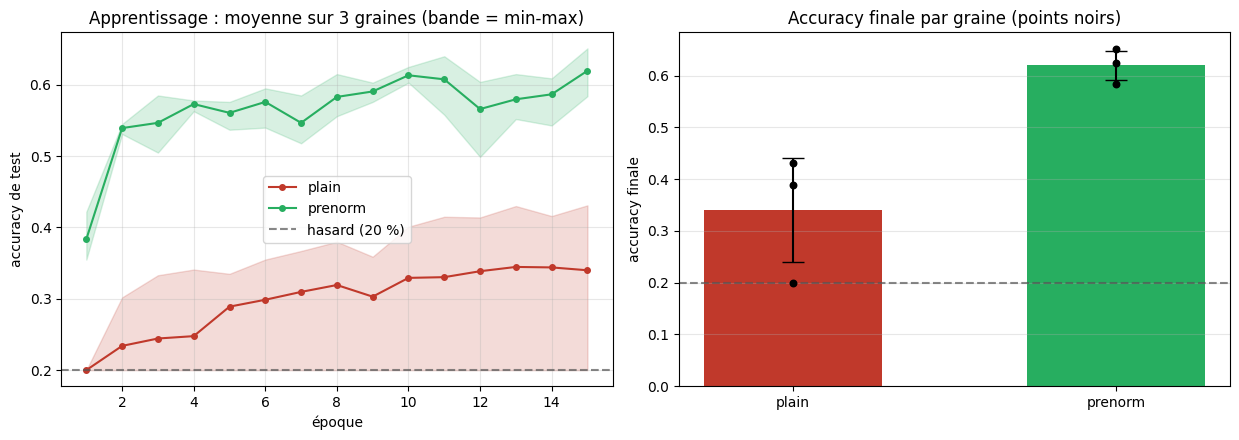

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.5))
epoques = np.arange(1, len(courbes[("plain", 0)]) + 1)
for mode, couleur in (("plain", "#c0392b"), ("prenorm", "#27ae60")):
    paquet = np.array([courbes[(mode, g)] for g in GRAINES])
    ax[0].plot(epoques, paquet.mean(0), "-o", color=couleur, label=mode, markersize=4)
    ax[0].fill_between(epoques, paquet.min(0), paquet.max(0), color=couleur, alpha=.18)
ax[0].axhline(1 / len(CLASSES), ls="--", color="#555", alpha=.7, label="hasard (20 %)")
ax[0].set_xlabel("époque"); ax[0].set_ylabel("accuracy de test")
ax[0].set_title("Apprentissage : moyenne sur 3 graines (bande = min-max)")
ax[0].grid(alpha=.3); ax[0].legend()

positions = np.arange(2)
ax[1].bar(positions, [finales[m].mean() for m in ("plain", "prenorm")],
          yerr=[finales[m].std() for m in ("plain", "prenorm")],
          color=["#c0392b", "#27ae60"], capsize=8, width=.55)
for i, m in enumerate(("plain", "prenorm")):
    ax[1].scatter([i] * len(GRAINES), finales[m], color="k", zorder=3, s=22)
ax[1].axhline(1 / len(CLASSES), ls="--", color="#555", alpha=.7)
ax[1].set_xticks(positions); ax[1].set_xticklabels(["plain", "prenorm"])
ax[1].set_ylabel("accuracy finale"); ax[1].set_title("Accuracy finale par graine (points noirs)")
ax[1].grid(alpha=.3, axis="y")
plt.tight_layout()
plt.show()

**Lecture — ce que la mesure autorise à dire, et ce qu'elle n'autorise pas.**

Les chiffres : `prenorm` finit à **62,0 % ± 2,8**, `plain` à **34,0 % ± 10,0**. L'écart vaut **+28,0 points** pour un bruit inter-graines de **±10,4**, soit un rapport écart/bruit de **2,7**. C'est ce rapport qui compte, pas les points d'écart pris isolément : sans les trois graines, aucune des deux quantités ne serait disponible.

Un détail mérite d'être regardé. L'écart-type de `plain` (±10,0) vaut près de quatre fois celui de `prenorm` (±2,8), et l'une des trois graines `plain` finit à **exactement 20,0 %** — le hasard sur cinq classes équilibrées. La dispersion de `plain` n'est pas un halo graduel autour d'une moyenne : elle est **bimodale**, certaines graines apprennent, d'autres ne démarrent jamais. C'est la signature d'un régime au bord de l'effondrement, cohérente avec le diagnostic de gradient de la section 3.

Deux précautions honnêtes sur la portée de ce résultat :

- **Ce n'est pas un benchmark.** Vingt blocs à 16 canaux sur 8x8 pixels, quinze époques, 5000 images : ce réseau n'est pas conçu pour maximiser l'accuracy sur CIFAR-10, il est conçu pour **isoler l'effet du branchement résiduel**, tout le reste étant tenu constant. Les valeurs absolues n'ont pas vocation à être comparées à la littérature.
- **La profondeur est ici un handicap assumé.** À 20 blocs sur ce budget, `plain` se trouve précisément dans le régime où l'effondrement du gradient mord. Un réseau `plain` de 4 blocs apprendrait très bien — c'est ce que l'exercice 1 fait vérifier. Le résiduel ne rend pas un réseau meilleur *en général* ; il rend la **profondeur** utilisable.

Ce que la mesure établit : sur un protocole contrôlé, à nombre de convolutions et graines identiques, le branchement résiduel pré-norme change le résultat d'apprentissage — et pas seulement le diagnostic de gradient de la section 3.

***

## 8. Ce que ce notebook a établi

Cinq mesures, dans l'ordre où elles ont été faites :

| # | mesure | résultat |
|---|---|---|
| 3 | gradient par couche, 20 convolutions empilées nues | rapport `g_0 / g_19` de l'ordre de **1e-08** : la première couche ne reçoit rien |
| 4 | skip naïf `h + act(conv(h))` | gradient **réparé**, mais `|h|` dérive d'un facteur ~90 et la perte initiale monte à ~17 au lieu de `ln 5 = 1,61` |
| 5 | bloc pré-norme `h + conv(act(norm(h)))` | rapport **~1,0**, activations bornées, perte initiale saine — les trois critères tenus ensemble |
| 6 | même protocole sur 20 blocs d'attention nus | rapport de gradients **plat** (`0,92`), mais `\|h\|` divisé par **2,1e+07** et `\|g\|` sept ordres de grandeur sous la pré-norme |
| 7 | accuracy CIFAR-10 (5 classes, 3 graines) | `prenorm` **62,0 % ± 2,8** contre `plain` **34,0 % ± 10,0** : écart **+28,0 points** pour un bruit de **±10,4**, soit un rapport de **2,7** |

**Le raisonnement en une ligne.** La dérivée d'un bloc résiduel est `I + ∂F/∂h`. Le terme `I` est une route non atténuée de la perte jusqu'à la couche 0 ; c'est lui qui remplace un produit de vingt jacobiennes (qui décroît géométriquement) par une somme (qui ne décroît pas). Le pré-norme est ce qui permet de garder cette route **nue** tout en bornant ce qu'on ajoute.

**Pourquoi l'ordre norm/skip n'est pas un détail.** `h + F(norm(h))` préserve `I` ; `norm(h + F(h))` le détruit. C'est la différence entre ResNet-v1 et ResNet-v2 en vision, et exactement la même entre Transformer post-norme et pré-norme en NLP. L'exercice 2 la fait mesurer.

**Le lien avec la série.** [3.4](../03-DeepLearning/3.4-Attention-Transformer-From-Scratch.ipynb) construit le bloc `h + attention(LayerNorm(h))` sans mesurer pourquoi il est ainsi ; la section 6 le mesure, sur de l'attention. Le résultat y est plus fin qu'un transfert littéral : sans skip, le rapport de gradients reste **plat** alors que le signal avant s'annihile et que le gradient absolu tombe sept ordres de grandeur sous celui du bloc pré-norme. Même cause, symptôme différent, même réparation. Le skip n'est pas une astuce de vision : c'est la condition qui rend n'importe quel empilement profond entraînable.

***

## 9. Exercices

Trois exercices, du plus direct au plus ouvert. Chacun se résout en modifiant ou en étendant du code déjà présent dans ce notebook — aucun n'exige de nouvelle bibliothèque.

### Exercice 1 : à partir de quelle profondeur `plain` décroche-t-il ?

La section 7 compare `plain` et `prenorm` à une profondeur fixée (20 blocs), où l'effondrement mord déjà. Mais l'affirmation « le résiduel rend la profondeur utilisable » implique quelque chose de plus précis : à **faible** profondeur, `plain` devrait tenir sans skip.

**Travail attendu**

1. Entraîner `plain` et `prenorm` pour `depth` dans `[4, 8, 12, 20]`, avec une seule graine et 8 époques (budget ~1 min au total : le coût croît avec la profondeur).
2. Tracer l'accuracy finale en fonction de `depth`, une courbe par architecture.
3. Répondre par écrit : à quelle profondeur les deux courbes se séparent-elles ? Cette profondeur coïncide-t-elle avec celle où le rapport `g_0 / g_D` de la section 5 franchit un seuil (disons 1e-3) ?

In [17]:
# Exercice 1 - à compléter
#
# profondeurs = [4, 8, 12, 20]
# resultats = {}
# for mode in ("plain", "prenorm"):
#     for d in profondeurs:
#         # Indice : `entrainer` fixe depth=20 en dur. Ajoutez-lui un paramètre
#         # `depth`, ou recopiez son corps ici en faisant varier la profondeur.
#         resultats[(mode, d)] = ...   # accuracy finale
#
# Étape 2 : une figure, deux courbes accuracy = f(profondeur).
#
# Étape 3 : comparer au rapport g0/gD déjà calculé en section 5 (variable
#           `rapports`), et écrire la conclusion en commentaire ou en markdown.

print("À compléter")

À compléter


### Exercice 2 : post-norme — quand la branche identité n'est plus nue

La section 5 affirme que l'ordre compte : `h + F(norm(h))` (pré-norme) préserve le terme `I`, tandis que `norm(h + F(h))` (post-norme) le détruit, parce que le chemin identité traverse alors la normalisation. C'est une affirmation testable.

**Travail attendu**

1. Ajouter un quatrième mode `postnorm` à `ConvStack`, dont la ligne de composition est `h = norm(h + act(conv(h)))`.
2. Mesurer son profil de gradient avec `mesure_gradient`, et l'ajouter au tableau comparatif de la section 5.
3. Répondre : le rapport `g_0 / g_19` de `postnorm` ressemble-t-il davantage à `plain` ou à `prenorm` ? Les activations restent-elles bornées ? Conclure sur ce que la normalisation répare et ce qu'elle ne répare pas.

In [18]:
# Exercice 2 - à compléter
#
# Étape 1 : sous-classer ConvStack (ou modifier sa méthode forward) pour
#           ajouter le mode "postnorm" :
#
#     h = norm(h + self.act(conv(h)))
#
#     class ConvStackPostNorm(ConvStack):
#         def forward(self, x, trace=None):
#             ...
#
# Étape 2 : g_post, h_post, l_post = mesure_gradient("postnorm")
#           puis reprendre le tableau de la section 5 avec quatre lignes.
#
# Étape 3 : conclusion écrite. Indice : la normalisation borne les
#           activations même en post-norme ; la question est de savoir si
#           elle préserve la route du gradient jusqu'a la couche 0.

print("À compléter")

À compléter


### Exercice 3 : combien de skips faut-il, et où ?

Les sections précédentes opposent deux extrêmes : zéro skip (`plain`) ou vingt skips (`prenorm`). Rien n'oblige à choisir l'un des deux. Si le rôle du skip est bien d'ouvrir une route pour le gradient, alors retirer les skips des `k` **derniers** blocs ne devrait pas beaucoup gêner la couche 0 — tandis que les retirer des `k` **premiers** devrait la couper de la perte.

**Travail attendu**

1. Écrire une variante de `ConvStack` acceptant un ensemble d'indices de blocs `sans_skip`, où la composition retombe sur `h = act(conv(h))`.
2. Mesurer le rapport `g_0 / g_19` pour `k` dans `[0, 5, 10, 15, 20]`, dans les deux dispositions : skips retirés en fin de réseau, puis en début.
3. Répondre : les deux courbes sont-elles symétriques ? Si non, la dissymétrie s'explique-t-elle par le sens de propagation du gradient (de la perte vers l'entrée) ?

In [19]:
# Exercice 3 - à compléter
#
# Étape 1 : une ConvStack acceptant `sans_skip` (un set d'indices de blocs).
#
#     class ConvStackPartiel(ConvStack):
#         def __init__(self, *args, sans_skip=frozenset(), **kw):
#             super().__init__(*args, **kw)
#             self.sans_skip = set(sans_skip)
#         def forward(self, x, trace=None):
#             # bloc k dans self.sans_skip  ->  h = self.act(conv(h))
#             # sinon                       ->  h = h + conv(self.act(norm(h)))
#             ...
#
# Étape 2 : pour k dans [0, 5, 10, 15, 20], deux dispositions :
#             fin   = range(20 - k, 20)
#             debut = range(k)
#           relever g[0] / g[-1] dans chaque cas.
#
# Étape 3 : tracer les deux courbes et répondre à la question de la symétrie.

print("À compléter")

À compléter


***

## Pour aller plus loin

- **He et al., *Deep Residual Learning for Image Recognition* (2015)** — l'article ResNet original : le point de départ y est exactement l'observation de la section 3, un réseau de 56 couches qui fait *moins* bien qu'un réseau de 20 couches.
- **He et al., *Identity Mappings in Deep Residual Networks* (2016)** — ResNet-v2, c'est-à-dire précisément le passage de la post-norme à la pré-norme mesuré en exercice 2.
- **Xiong et al., *On Layer Normalization in the Transformer Architecture* (2020)** — la même analyse, côté NLP : pourquoi les Transformers pré-norme s'entraînent sans phase de chauffe là où les post-norme en ont besoin.

**Suite de la série** : [4.3 — transfert et fine-tuning](../README.md) *(voir feuille de route)*, où le réseau résiduel cesse d'être entraîne de zéro et devient un extracteur de représentations pré-entraîné.